# Finding Eigenvalues by Hand

**This notebook is self-contained; it recaps what an eigenvector is before computing one.**

The previous notebook showed what eigenvectors *look* like — the directions a transformation doesn't turn. This one **computes** them. The route is a single equation, $\det(A - \lambda I) = 0$, which converts the geometric question into a polynomial you can actually solve. The determinant from §2.5 is what makes it work.

## Learning objectives

- Set up and solve the **characteristic equation** $\det(A - \lambda I) = 0$ for a $2\times2$ matrix.
- Recover the **eigenvector** belonging to each eigenvalue.
- Verify a computed pair satisfies $A\mathbf{v} = \lambda\mathbf{v}$.
- Contrast **symmetric** and non-symmetric matrices.

## Background

An **eigenvector** is a nonzero $\mathbf{v}$ with $A\mathbf{v} = \lambda\mathbf{v}$ for some scalar $\lambda$, the **eigenvalue**. Move everything to one side:

$$A\mathbf{v} - \lambda\mathbf{v} = \mathbf{0} \quad\Longrightarrow\quad (A - \lambda I)\mathbf{v} = \mathbf{0}$$

where $I$ is the identity. Now the key step. A **nonzero** $\mathbf{v}$ can only be sent to $\mathbf{0}$ if the matrix $A - \lambda I$ **collapses space** — and from §2.5 that happens exactly when its determinant vanishes:

$$\boxed{\det(A - \lambda I) = 0}$$

This is the **characteristic equation**. For a $2\times2$ it is a quadratic in $\lambda$, so there are (at most) two eigenvalues. Solve it, then substitute each $\lambda$ back to find its eigenvector.

## This notebook covers

1. Building $A - \lambda I$ and expanding the determinant into a quadratic.
2. Solving for the eigenvalues.
3. Back-substituting to get each eigenvector.
4. Checking against `np.linalg.eig`.
5. Symmetric versus non-symmetric.

**Prerequisites:** `U2-6_Eigen-1_DirectionsThatDontTurn`, `U2-5_Determinants-1_AsArea`

**Dataset:** none — matrices are entered directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
# plotting helper: label the axis ends compactly (for grids of small panels)
def label_axes(ax, x='x', y='y', size=8):
    ax.set_xlabel(x, loc='right', fontsize=size)
    ax.set_ylabel(y, loc='top', rotation=0, fontsize=size)
# plotting helper: draw one vector as an arrow starting at `tail`
# (zorder keeps arrows on top of the axis spines, which are the same white)
def arrow(ax, tail, vec, color, label=None, alpha=1.0):
    ax.quiver(tail[0], tail[1], vec[0], vec[1], angles='xy', scale_units='xy',
              scale=1, color=color, label=label, alpha=alpha, width=0.011, zorder=5)

## 1. Set up the characteristic equation

Work with

$$A = \begin{bmatrix}4 & 1\\ 2 & 3\end{bmatrix}.$$

Subtracting $\lambda I$ takes $\lambda$ off the diagonal:

$$A - \lambda I = \begin{bmatrix}4 - \lambda & 1\\ 2 & 3 - \lambda\end{bmatrix}$$

Now take the determinant with $\det = ad - bc$:

$$\det(A - \lambda I) = (4-\lambda)(3-\lambda) - (1)(2) = \lambda^2 - 7\lambda + 10$$

Set it to zero and factor: $\lambda^2 - 7\lambda + 10 = (\lambda - 5)(\lambda - 2) = 0$, so

$$\lambda_1 = 5, \qquad \lambda_2 = 2.$$

In [2]:
A = np.array([[4.0, 1.0],
              [2.0, 3.0]])
helpers.show(A, name="A")

# the determinant of (A - lambda I), evaluated at a few lambdas
for lam in [0, 2, 3, 5]:
    M = A - lam * np.eye(2)
    print(f"lambda = {lam}:  det(A - {lam}I) = {np.linalg.det(M):6.1f}"
          + ("   <- zero, so this is an eigenvalue" if np.isclose(np.linalg.det(M), 0) else ""))

<IPython.core.display.Math object>

lambda = 0:  det(A - 0I) =   10.0
lambda = 2:  det(A - 2I) =    0.0   <- zero, so this is an eigenvalue
lambda = 3:  det(A - 3I) =   -2.0
lambda = 5:  det(A - 5I) =    0.0   <- zero, so this is an eigenvalue


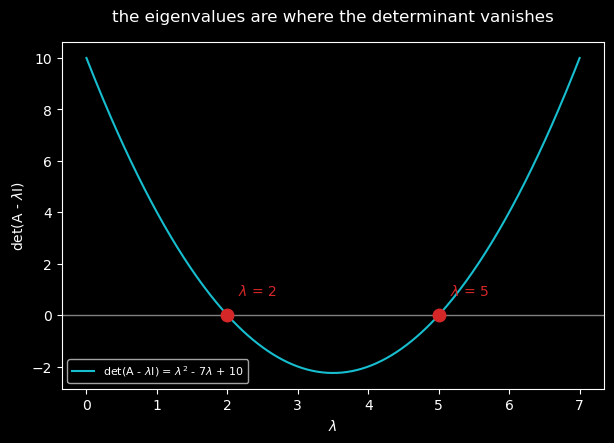

In [3]:
# the same thing as a curve: the characteristic polynomial, and where it crosses zero
lams = np.linspace(0, 7, 300)
dets = [np.linalg.det(A - l * np.eye(2)) for l in lams]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(lams, dets, color="tab:cyan", label=r"det(A - $\lambda$I) = $\lambda^2$ - 7$\lambda$ + 10")
ax.axhline(0, color="gray", lw=1)
for root in [2, 5]:
    ax.plot(root, 0, "o", color="tab:red", markersize=9)
    ax.annotate(f"$\\lambda$ = {root}", (root, 0), textcoords="offset points",
                xytext=(8, 14), color="tab:red")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"det(A - $\lambda$I)")
ax.legend(fontsize=8)
ax.set_title("the eigenvalues are where the determinant vanishes", pad=15)
plt.show()

## 2. Back-substitute for the eigenvectors

An eigenvalue on its own is only half the answer. Put $\lambda = 5$ back into $(A - \lambda I)\mathbf{v} = \mathbf{0}$:

$$\begin{bmatrix}4-5 & 1\\ 2 & 3-5\end{bmatrix}\begin{bmatrix}v_1\\v_2\end{bmatrix} = \begin{bmatrix}-1 & 1\\ 2 & -2\end{bmatrix}\begin{bmatrix}v_1\\v_2\end{bmatrix} = \begin{bmatrix}0\\0\end{bmatrix}$$

Both rows say the same thing — $-v_1 + v_2 = 0$, i.e. $v_1 = v_2$. (They *must* agree: that redundancy is exactly what $\det = 0$ guarantees.) So any multiple of $\begin{bmatrix}1\\1\end{bmatrix}$ works.

**Eigenvectors are directions, not specific arrows** — scale one and it is still an eigenvector. By convention we report the version of length 1.

Repeating for $\lambda = 2$ gives $2v_1 + v_2 = 0$, so $\mathbf{v} \propto \begin{bmatrix}1\\-2\end{bmatrix}$.

In [4]:
for lam, guess in [(5.0, np.array([1.0, 1.0])), (2.0, np.array([1.0, -2.0]))]:
    M = A - lam * np.eye(2)
    helpers.show(M, label=f"A - {lam:.0f}I")
    print(f"   det = {np.linalg.det(M):.1f} (zero, as required)")
    print(f"   trying v = {guess}:  (A - {lam:.0f}I) v = {M @ guess}  -> the zero vector\n")

<IPython.core.display.Math object>

   det = 0.0 (zero, as required)
   trying v = [1. 1.]:  (A - 5I) v = [0. 0.]  -> the zero vector



<IPython.core.display.Math object>

   det = 0.0 (zero, as required)
   trying v = [ 1. -2.]:  (A - 2I) v = [0. 0.]  -> the zero vector



In [5]:
# verify the defining property, and the elementwise A@v / v trick:
# if v really is an eigenvector, every entry of this ratio is the same number -- the eigenvalue
for lam, v in [(5.0, np.array([1.0, 1.0])), (2.0, np.array([1.0, -2.0]))]:
    helpers.show(v, label=f"eigenvector for lambda = {lam:.0f}")
    helpers.show(A @ v, label="A times it")
    print(f"   elementwise (A v) / v = {A @ v / v}   -> both entries equal {lam:.0f}\n")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

   elementwise (A v) / v = [5. 5.]   -> both entries equal 5



<IPython.core.display.Math object>

<IPython.core.display.Math object>

   elementwise (A v) / v = [2. 2.]   -> both entries equal 2



## 3. Check against NumPy

`np.linalg.eig` returns the eigenvalues as an array and the eigenvectors as the **columns** of a matrix, each normalized to length 1. Our hand answers should match up to that scaling.

In [6]:
vals, vecs = np.linalg.eig(A)
helpers.show(np.round(vals, 3), label="eigenvalues from numpy")
helpers.show(np.round(vecs, 3), label="eigenvectors, as columns")

# our by-hand directions, normalized the same way, for comparison
for v in [np.array([1.0, 1.0]), np.array([1.0, -2.0])]:
    helpers.show(np.round(v / np.linalg.norm(v), 3), label="our answer, scaled to length 1")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

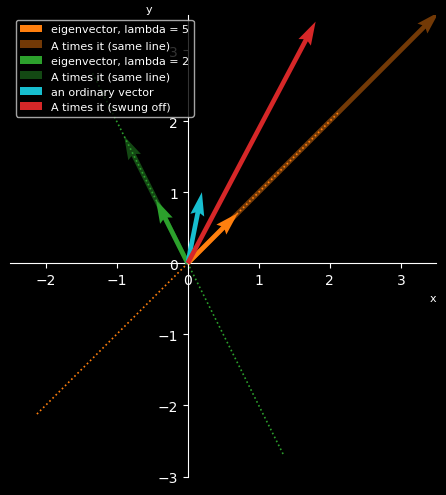

In [7]:
# the picture: eigen-directions stay on their line, a non-eigenvector doesn't
fig, ax = plt.subplots(figsize=(7, 6))
for k, color in zip(range(2), ["tab:orange", "tab:green"]):
    v, lam = vecs[:, k], vals[k]
    line = np.array([-3 * v, 3 * v]).T
    ax.plot(line[0], line[1], ":", color=color, lw=1.2)
    arrow(ax, (0, 0), v, color, f"eigenvector, lambda = {lam:.0f}")
    arrow(ax, (0, 0), A @ v, color, "A times it (same line)", alpha=0.45)

other = np.array([0.2, 1.0])
arrow(ax, (0, 0), other, "tab:cyan", "an ordinary vector")
arrow(ax, (0, 0), A @ other, "tab:red", "A times it (swung off)")

center_axes(ax); label_axes(ax)
ax.set_xlim(-2.5, 3.5); ax.set_ylim(-3, 3.5); ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=8)
plt.show()

## 4. Symmetric matrices are special

A matrix is **symmetric** when $A = A^{\top}$ — it reads the same across the diagonal. Symmetric matrices come with two guarantees:

1. their eigenvalues are always **real** (never complex), and
2. their eigenvectors are always **perpendicular** to each other.

Neither holds in general. The matrix above is not symmetric, and its two eigenvectors are *not* at right angles. A rotation matrix has no real eigenvalues at all — sensibly, since it turns every direction.

This matters because §2.7's **covariance matrix is always symmetric**. That guarantee is why PCA reliably produces clean perpendicular axes.

In [8]:
def report(name, M):
    vals, vecs = np.linalg.eig(M)
    sym = np.allclose(M, M.T)
    print(f"{name}")
    print(f"   symmetric? {sym}")
    print(f"   eigenvalues: {np.round(vals, 3)}")
    if np.isrealobj(vals):
        ang = np.degrees(np.arccos(np.clip(
            np.dot(vecs[:, 0], vecs[:, 1]) /
            (np.linalg.norm(vecs[:, 0]) * np.linalg.norm(vecs[:, 1])), -1, 1)))
        print(f"   angle between eigenvectors: {ang:.1f} deg")
    else:
        print("   complex -> no real eigenvector; this transformation rotates everything")
    print()

report("A (from this notebook, not symmetric)", A)
report("a symmetric matrix", np.array([[2.0, 1.0], [1.0, 2.0]]))
report("a rotation by 60 degrees", np.array([[np.cos(np.radians(60)), -np.sin(np.radians(60))],
                                             [np.sin(np.radians(60)),  np.cos(np.radians(60))]]))

A (from this notebook, not symmetric)
   symmetric? False
   eigenvalues: [5. 2.]
   angle between eigenvectors: 71.6 deg

a symmetric matrix
   symmetric? True
   eigenvalues: [3. 1.]
   angle between eigenvectors: 90.0 deg

a rotation by 60 degrees
   symmetric? False
   eigenvalues: [0.5+0.866j 0.5-0.866j]
   complex -> no real eigenvector; this transformation rotates everything



## 5. Summary

- $A\mathbf{v} = \lambda\mathbf{v}$ rearranges to $(A - \lambda I)\mathbf{v} = \mathbf{0}$, which needs $A - \lambda I$ to collapse space — so $\det(A - \lambda I) = 0$.
- That **characteristic equation** is a quadratic for a $2\times2$; its roots are the eigenvalues.
- **Back-substitute** each $\lambda$ to get its eigenvector; eigenvectors are **directions**, fixed only up to scale.
- Quick check: if $\mathbf{v}$ is an eigenvector, every entry of `A @ v / v` is the same number.
- **Symmetric** matrices guarantee real eigenvalues and perpendicular eigenvectors — the foundation of §2.7.

Next: finding the dominant eigenvector by sheer repetition (`U2-6_Eigen-3_PowerMethodAndPageRank`).